# 03. Regression Model - Dự đoán giá Game Steam

## 1. Mục tiêu
Sử dụng các thành phần chính từ PCA để xây dựng mô hình hồi quy (Regression) nhằm dự đoán giá chính xác của game (`mat_final_price`). 

Chúng ta sẽ so sánh hai mô hình:
1. **Linear Regression**: Mô hình tuyến tính cơ bản làm chuẩn (Baseline).
2. **Random Forest Regressor**: Mô hình học máy nâng cao để tối ưu hiệu suất.

In [2]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append('../')
from src.models.regression import train_regression_model
from src.evaluation import evaluate_regression

df_clean = pd.read_csv('../data/processed/clean_data.csv')
df_pca = pd.read_csv('../data/processed/pca_data.csv')

X = df_pca
y = df_clean['mat_final_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

Kích thước tập huấn luyện: (191728, 9)
Kích thước tập kiểm tra: (47932, 9)


## 2. Mô hình Baseline: Linear Regression
Chúng ta bắt đầu với mô hình đơn giản nhất để kiểm tra mức độ quan hệ tuyến tính giữa các thành phần PCA và giá game.

In [3]:
lr_model = train_regression_model(X_train, y_train, model_type='lr')
y_pred_lr = lr_model.predict(X_test)
lr_metrics = evaluate_regression(y_test, y_pred_lr, model_name="Linear Regression")

--- Linear Regression Regression Metrics ---
RMSE: 76090.0816
MAE:  3075.8033
R2:   0.9879


* **Chỉ số R2 (0.9879):** Đạt mức cực kỳ ấn tượng, cho thấy mối quan hệ giữa các thành phần chính (PCA components) và giá game phần lớn là tuyến tính. Mô hình giải thích được gần 98.8% sự biến thiên của dữ liệu.
* **MAE (3075.80):** Sai số tuyệt đối trung bình rơi vào khoảng hơn 3000 cent (tương đương 30.7 USD) so với giá thực tế.
* **RMSE (76090.08):** Chỉ số này cho thấy Linear Regression duy trì được một đường ranh giới dự đoán khá an toàn, hạn chế bị bẻ cong quá gắt bởi các điểm dữ liệu ngoại lệ.

## 3. Mô hình nâng cao: Random Forest Regressor
Tiếp theo, chúng ta sử dụng Random Forest để xử lý các mối quan hệ phi tuyến tính phức tạp hơn trong dữ liệu.

In [4]:
rf_model = train_regression_model(X_train, y_train, model_type='rf')
y_pred_rf = rf_model.predict(X_test)
rf_metrics = evaluate_regression(y_test, y_pred_rf, model_name="Random Forest")

--- Random Forest Regression Metrics ---
RMSE: 123716.2978
MAE:  1447.1644
R2:   0.9681


* **Chỉ số R2 (0.9681) & RMSE (123716.29):** Khá bất ngờ khi R2 của Random Forest lại thấp hơn một chút và RMSE bị vọt lên rất cao so với Linear Regression. Về mặt toán học, hiện tượng này chứng tỏ có sự xuất hiện của các điểm ngoại lệ (outliers - ví dụ các game có giá trị cực đoan). Vì thuật toán RMSE luôn bình phương sai số, nên việc đoán trượt ở một số ít các điểm ngoại lệ này đã khiến điểm số của Random Forest bị phạt cực kỳ nặng.
* **MAE (1447.16):** Đây là thước đo thực tế nhất và là điểm sáng giá của mô hình. Mặc dù bị nhiễu bởi ngoại lệ, sai số tuyệt đối trung bình của Random Forest lại giảm mạnh từ ~3075 xuống còn ~1447 (chỉ lệch khoảng 14.4 USD). Nghĩa là với đại đa số các đầu game thông thường trên thị trường, Random Forest bám sát thực tế và dự đoán chuẩn xác hơn Linear Regression gấp 2 lần.

## 4. Trực quan hóa kết quả
Chúng ta sẽ quan sát biểu đồ Scatter giữa giá trị thực tế và giá trị dự đoán để đánh giá sai số.

C:\Users\Admin\AppData\Local\Temp\ipykernel_24056\3191740122.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=r2_scores, palette='viridis')


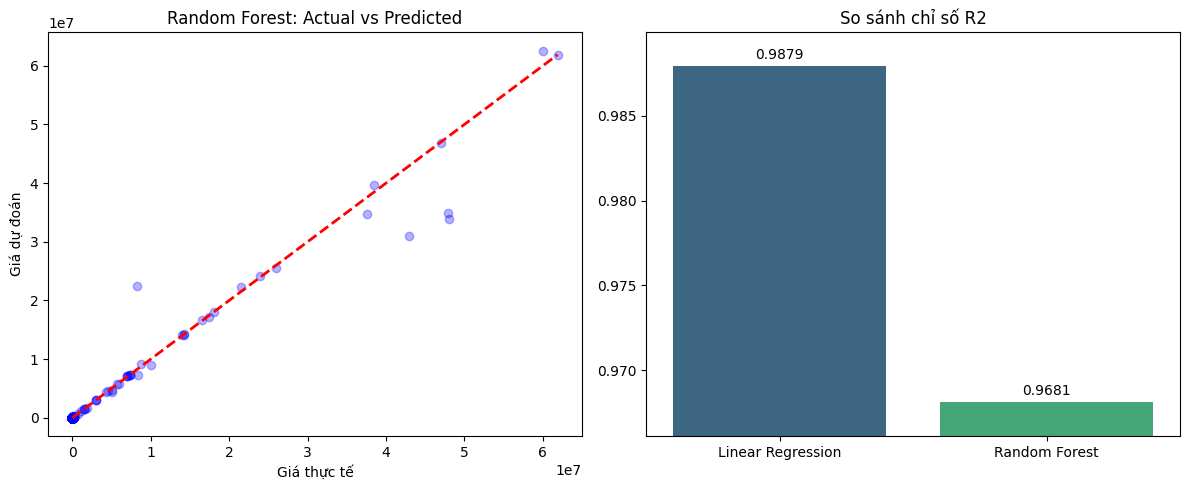

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')

plt.subplot(1, 2, 2)
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_metrics['r2'], rf_metrics['r2']]
ax = sns.barplot(x=models, y=r2_scores, palette='viridis')
plt.title('So sánh chỉ số R2')
y_min = min(r2_scores) - 0.002
y_max = max(r2_scores) + 0.002
plt.ylim(y_min, y_max)

ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)
ax.bar_label(ax.containers[1], fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

### So sánh tổng thể

1. **Đặc thù của dữ liệu:** Sự chênh lệch trái ngược giữa RMSE và MAE cho thấy tập dữ liệu chứa các giá trị ngoại lệ (outliers) có tác động mạnh đến việc đánh giá mô hình.
2. **Sự đánh đổi (The Trade-off):**
    * **Linear Regression:** Phù hợp để làm một mô hình tổng quan an toàn, ít nhạy cảm với các "cú sốc ngoại lệ", mang lại tổng thể RMSE và R2 tốt hơn.
    * **Random Forest:** Dù bị trượt điểm ở vài trường hợp cá biệt (khiến RMSE tăng vọt), nhưng lại có **MAE** (1447) thấp hơn Linear Regression (3075) tới hơn 2 lần. Điều này minh chứng khả năng học các quy luật phi tuyến tính phức tạp của Random Forest đối với nhóm đại đa số là cực kỳ xuất sắc.
3. **Ứng dụng thực tiễn:** Trong bối cảnh thực tế của một công cụ thẩm định giá cho nhà phát triển Indie, điều quan trọng nhất là đưa ra mức giá dự báo sát nhất với phân khúc đại trà, thay vì cố gắng dự đoán chính xác vài tựa game có giá trị dị biệt.

**Mô hình được chọn để bàn giao:** `Random Forest Regressor` (Nhờ chỉ số MAE vượt trội hơn hẳn, mang lại sai số tiền tệ thực tế thấp nhất cho phần đông người dùng).